In [3]:
import os, json

# Load configs from previous notebooks
nb1_config_path = '/kaggle/input/notebooks/asmidagar12/notebook1/config.json'
nb2_config_path = '/kaggle/input/notebooks/asmidagar12/notebook2/nb2_config.json'

with open(nb1_config_path) as f:
    nb1_config = json.load(f)

with open(nb2_config_path) as f:
    nb2_config = json.load(f)

DATASET_ROOT    = nb1_config['DATASET_ROOT']
TRAIN_IMG       = nb1_config['TRAIN_IMG']
TRAIN_LBL       = nb1_config['TRAIN_LBL']
VAL_IMG         = nb1_config['VAL_IMG']
VAL_LBL         = nb1_config['VAL_LBL']
TEST_IMG        = nb1_config['TEST_IMG']
TEST_LBL        = nb1_config['TEST_LBL']
CLASS_NAMES     = nb1_config['CLASS_NAMES']
BEST_MODEL_PATH = '/kaggle/input/notebooks/asmidagar12/notebook2/fire_smoke_detector2/weights/best.pt'
OUTPUT_DIR      = '/kaggle/working'

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configs loaded!")
print(f"Dataset     : {DATASET_ROOT}")
print(f"Best model  : {BEST_MODEL_PATH}")
print(f"Model exists: {os.path.exists(BEST_MODEL_PATH)}")

Configs loaded!
Dataset     : /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo
Best model  : /kaggle/input/notebooks/asmidagar12/notebook2/fire_smoke_detector2/weights/best.pt
Model exists: True


In [4]:
!pip install ultralytics tensorflow -q

import cv2
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO
from tqdm import tqdm
import torch
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("GPU available    :", torch.cuda.is_available())
print("TF GPU available :", len(tf.config.list_physical_devices('GPU')) > 0)
print("All libraries ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.8 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


E0000 00:00:1775732122.695597      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775732122.760652      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775732123.281168      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775732123.281209      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775732123.281212      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775732123.281215      55 computation_placer.cc:177] computation placer already registered. Please check linka

GPU available    : True
TF GPU available : True
All libraries ready!


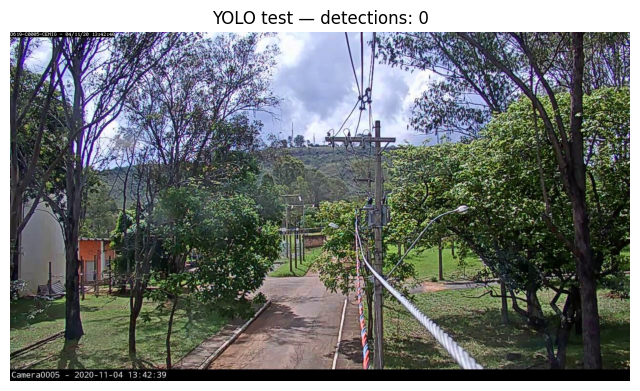

Model loaded and working! Detections: 0


In [5]:
# Load trained YOLO model
detector = YOLO(BEST_MODEL_PATH)

# Test on one image to confirm it works
test_files = [f for f in os.listdir(TEST_IMG)
              if f.endswith(('.jpg','.png','.jpeg'))]
sample     = random.choice(test_files)
img_path   = os.path.join(TEST_IMG, sample)

result = detector(img_path, conf=0.25, verbose=False)[0]
img    = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis('off')
plt.title(f'YOLO test — detections: {len(result.boxes)}', fontsize=12)
plt.savefig(os.path.join(OUTPUT_DIR, 'yolo_single_test.png'), dpi=100)
plt.show()
print(f"Model loaded and working! Detections: {len(result.boxes)}")

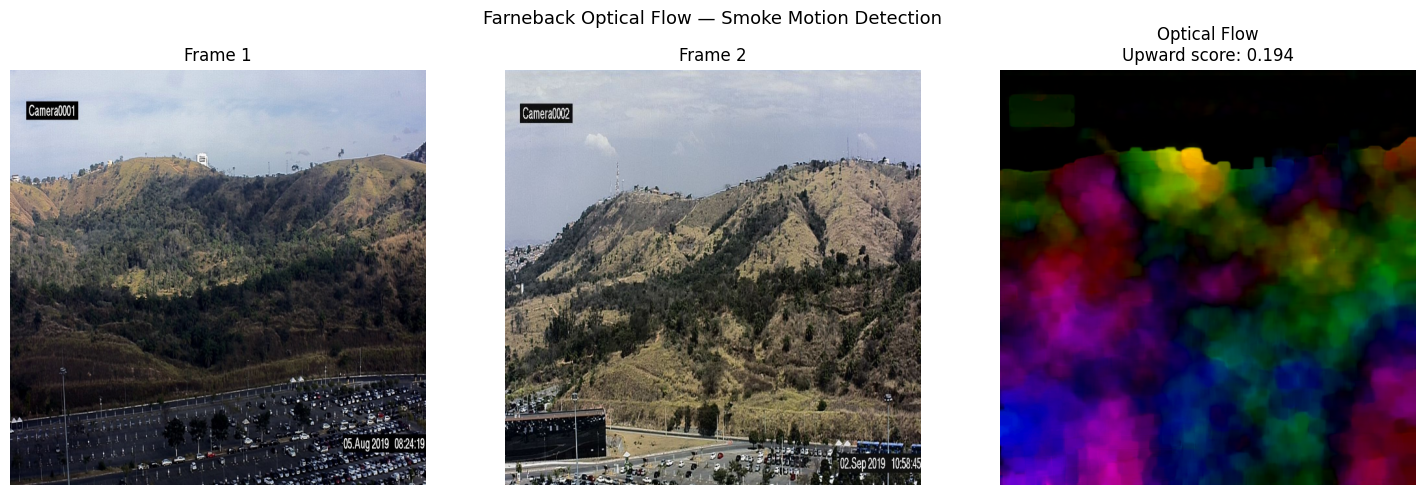

Upward motion score: 0.1944


In [6]:
def compute_optical_flow(frame1, frame2):
    """
    Compute Farneback optical flow between two frames.
    Returns magnitude and angle of motion vectors.
    """
    gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

    flow = cv2.calcOpticalFlowFarneback(
        gray1, gray2,
        None,
        pyr_scale  = 0.5,
        levels     = 3,
        winsize    = 15,
        iterations = 3,
        poly_n     = 5,
        poly_sigma = 1.2,
        flags      = 0
    )

    magnitude, angle = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    return magnitude, angle, flow

def get_upward_motion_score(magnitude, angle):
    """
    Score how much motion is going UPWARD (smoke rises).
    Upward motion = angle between 45 and 135 degrees.
    Returns score between 0 and 1.
    """
    upward_mask  = (angle > np.pi/4) & (angle < 3*np.pi/4)
    upward_mag   = magnitude[upward_mask]
    total_mag    = magnitude.sum()
    upward_score = upward_mag.sum() / (total_mag + 1e-6)
    return float(upward_score)

# Test optical flow on two consecutive images
img_files_sorted = sorted(test_files)
frame1 = cv2.imread(os.path.join(TEST_IMG, img_files_sorted[0]))
frame2 = cv2.imread(os.path.join(TEST_IMG, img_files_sorted[1]))

if frame1 is not None and frame2 is not None:
    frame1 = cv2.resize(frame1, (640, 640))
    frame2 = cv2.resize(frame2, (640, 640))

    magnitude, angle, flow = compute_optical_flow(frame1, frame2)
    upward_score = get_upward_motion_score(magnitude, angle)

    # Visualise optical flow
    hsv = np.zeros_like(frame1)
    hsv[..., 1] = 255
    hsv[..., 0] = angle * 180 / np.pi / 2
    hsv[..., 2] = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)
    flow_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Frame 1')
    axes[0].axis('off')
    axes[1].imshow(cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB))
    axes[1].set_title('Frame 2')
    axes[1].axis('off')
    axes[2].imshow(flow_rgb)
    axes[2].set_title(f'Optical Flow\nUpward score: {upward_score:.3f}')
    axes[2].axis('off')

    plt.suptitle('Farneback Optical Flow — Smoke Motion Detection', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'optical_flow.png'), dpi=100)
    plt.show()
    print(f"Upward motion score: {upward_score:.4f}")

In [7]:
def extract_frame_features(img_path, prev_img_path=None):
    """
    Extract features from a single frame using YOLO + optical flow.
    Returns a feature vector of length 8.
    """
    frame = cv2.imread(img_path)
    if frame is None:
        return np.zeros(8)
    frame = cv2.resize(frame, (640, 640))

    # YOLO detection features
    result     = detector(frame, conf=0.25, verbose=False)[0]
    boxes      = result.boxes
    n_fire     = sum(1 for c in boxes.cls if int(c) == 1)
    n_smoke    = sum(1 for c in boxes.cls if int(c) == 0)
    max_conf   = float(boxes.conf.max()) if len(boxes) > 0 else 0.0
    avg_conf   = float(boxes.conf.mean()) if len(boxes) > 0 else 0.0
    n_detect   = len(boxes)

    # Optical flow features
    upward_score  = 0.0
    flow_magnitude = 0.0
    if prev_img_path and os.path.exists(prev_img_path):
        prev_frame = cv2.imread(prev_img_path)
        if prev_frame is not None:
            prev_frame   = cv2.resize(prev_frame, (640, 640))
            mag, ang, _  = compute_optical_flow(prev_frame, frame)
            upward_score  = get_upward_motion_score(mag, ang)
            flow_magnitude = float(mag.mean())

    # Feature vector: 8 features per frame
    features = np.array([
        n_fire,          # number of fire detections
        n_smoke,         # number of smoke detections
        n_detect,        # total detections
        max_conf,        # highest confidence score
        avg_conf,        # average confidence score
        upward_score,    # upward motion (smoke rising)
        flow_magnitude,  # overall motion magnitude
        1.0 if (n_fire > 0 or n_smoke > 0) else 0.0  # binary detection flag
    ], dtype=np.float32)

    return features

print("Testing feature extraction on one image...")
sample_path = os.path.join(TEST_IMG, test_files[0])
features    = extract_frame_features(sample_path)
feature_names = ['n_fire','n_smoke','n_detect','max_conf',
                 'avg_conf','upward_score','flow_mag','detected']

print("\nFeature vector:")
for name, val in zip(feature_names, features):
    print(f"  {name:15s}: {val:.4f}")

Testing feature extraction on one image...

Feature vector:
  n_fire         : 2.0000
  n_smoke        : 0.0000
  n_detect       : 2.0000
  max_conf       : 0.5669
  avg_conf       : 0.4719
  upward_score   : 0.0000
  flow_mag       : 0.0000
  detected       : 1.0000


In [8]:
SEQUENCE_LEN = 10   # 10 consecutive frames per sequence
N_FEATURES   = 8    # features per frame

print("Building LSTM training sequences from train set...")
print("This takes ~10 minutes...\n")

train_img_list = sorted([
    f for f in os.listdir(TRAIN_IMG)
    if f.endswith(('.jpg','.png','.jpeg'))
])

# Use 2000 images for speed (enough for good LSTM training)
sample_size   = min(2000, len(train_img_list))
sampled_imgs  = train_img_list[:sample_size]

all_sequences = []
all_labels    = []

for i in tqdm(range(0, len(sampled_imgs) - SEQUENCE_LEN, SEQUENCE_LEN)):
    sequence  = []
    has_fire  = False

    for j in range(SEQUENCE_LEN):
        idx       = i + j
        img_path  = os.path.join(TRAIN_IMG, sampled_imgs[idx])
        prev_path = os.path.join(TRAIN_IMG, sampled_imgs[idx-1]) if idx > 0 else None
        lbl_path  = os.path.join(TRAIN_LBL,
                        sampled_imgs[idx].replace('.jpg','.txt')
                                         .replace('.png','.txt')
                                         .replace('.jpeg','.txt'))

        features = extract_frame_features(img_path, prev_path)
        sequence.append(features)

        # Label: 1 if any frame in sequence has fire/smoke
        if os.path.exists(lbl_path):
            with open(lbl_path) as f:
                if f.read().strip():
                    has_fire = True

    all_sequences.append(sequence)
    all_labels.append(1 if has_fire else 0)

X = np.array(all_sequences, dtype=np.float32)
y = np.array(all_labels,    dtype=np.float32)

print(f"\nDataset built!")
print(f"  X shape  : {X.shape}  (sequences, timesteps, features)")
print(f"  y shape  : {y.shape}")
print(f"  Fire/smoke sequences : {y.sum():.0f} ({y.mean()*100:.1f}%)")
print(f"  Empty sequences      : {(1-y).sum():.0f} ({(1-y).mean()*100:.1f}%)")

Building LSTM training sequences from train set...
This takes ~10 minutes...



100%|██████████| 199/199 [05:57<00:00,  1.80s/it]


Dataset built!
  X shape  : (199, 10, 8)  (sequences, timesteps, features)
  y shape  : (199,)
  Fire/smoke sequences : 4 (2.0%)
  Empty sequences      : 195 (98.0%)


In [9]:
from sklearn.model_selection import train_test_split

# Normalise features
X_flat     = X.reshape(-1, N_FEATURES)
scaler     = MinMaxScaler()
X_scaled   = scaler.fit_transform(X_flat).reshape(X.shape)

# Train/val split
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

print(f"Train sequences : {X_train.shape[0]}")
print(f"Val sequences   : {X_val.shape[0]}")
print(f"Input shape     : {X_train.shape}")

# Save scaler for inference
import pickle
scaler_path = os.path.join(OUTPUT_DIR, 'lstm_scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Scaler saved to : {scaler_path}")

Train sequences : 159
Val sequences   : 40
Input shape     : (159, 10, 8)
Scaler saved to : /kaggle/working/lstm_scaler.pkl


In [10]:
# Build LSTM model
lstm_model = Sequential([
    LSTM(64, input_shape=(SEQUENCE_LEN, N_FEATURES),
         return_sequences=True),
    Dropout(0.3),
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1,  activation='sigmoid')
], name='fire_lstm')

lstm_model.compile(
    optimizer = 'adam',
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy', tf.keras.metrics.AUC(name='auc')]
)

lstm_model.summary()

# Callbacks
callbacks = [
    EarlyStopping(
        monitor  = 'val_auc',
        patience = 5,
        mode     = 'max',
        verbose  = 1,
        restore_best_weights = True
    ),
    ModelCheckpoint(
        filepath         = os.path.join(OUTPUT_DIR, 'lstm_best.h5'),
        monitor          = 'val_auc',
        save_best_only   = True,
        mode             = 'max',
        verbose          = 1
    )
]

print("\nTraining LSTM... (takes ~5 minutes)")
history = lstm_model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = 30,
    batch_size      = 32,
    callbacks       = callbacks,
    verbose         = 1
)

I0000 00:00:1775732510.626394      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13679 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775732510.631570      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "fire_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,649 (123.63 KB)

 Trainable params: 31,649 (123.63 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM... (takes ~5 minutes)
Epoch 1/30


I0000 00:00:1775732515.346874     166 cuda_dnn.cc:529] Loaded cuDNN version 91002


1/5 ━━━━━━━━━━━━━━━━━━━━ 22s 6s/step - accuracy: 0.4375 - auc: 0.0000e+00 - loss: 0.6936
Epoch 1: val_auc improved from -inf to 0.14103, saving model to /kaggle/working/lstm_best.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 162ms/step - accuracy: 0.6612 - auc: 0.3356 - loss: 0.6891 - val_accuracy: 0.9750 - val_auc: 0.1410 - val_loss: 0.6705
Epoch 2/30
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 0.6687
Epoch 2: val_auc did not improve from 0.14103
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9868 - auc: 0.5548 - loss: 0.6632 - val_accuracy: 0.9750 - val_auc: 0.1282 - val_loss: 0.6377
Epoch 3/30
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 0.6398
Epoch 3: val_auc did not improve from 0.14103
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9881 - auc: 0.3293 - loss: 0.6312 - val_accuracy: 0.9750 - val_auc: 0.0769 - val_loss: 0.5799
Epoch 4/30
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9375 - auc: 0.7917 - loss: 0.5838
Epoch 4: val_auc did not improve from 0.14103
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9707 - auc: 0.7108 - loss: 0.5612 - val_accuracy: 0.9750 - val_auc: 0.07

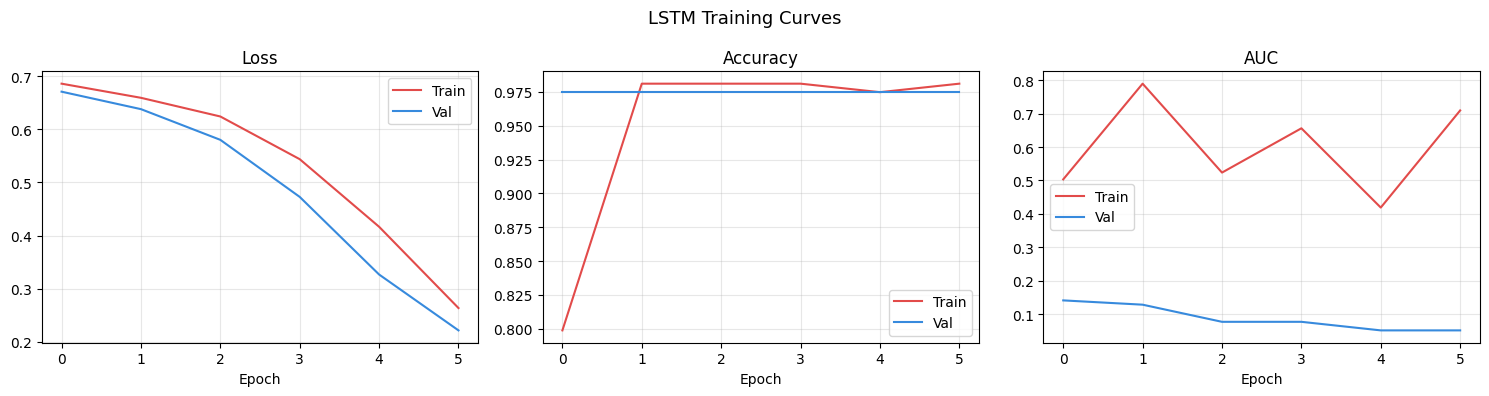

Saved LSTM training curves!


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('LSTM Training Curves', fontsize=13)

axes[0].plot(history.history['loss'],     label='Train', color='#E24B4A')
axes[0].plot(history.history['val_loss'], label='Val',   color='#378ADD')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train', color='#E24B4A')
axes[1].plot(history.history['val_accuracy'], label='Val',   color='#378ADD')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history.history['auc'],     label='Train', color='#E24B4A')
axes[2].plot(history.history['val_auc'], label='Val',   color='#378ADD')
axes[2].set_title('AUC')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'lstm_training_curves.png'), dpi=100)
plt.show()
print("Saved LSTM training curves!")

=== LSTM PERFORMANCE ===
              precision    recall  f1-score   support

     No Fire       0.97      1.00      0.99        39
  Fire/Smoke       0.00      0.00      0.00         1

    accuracy                           0.97        40
   macro avg       0.49      0.50      0.49        40
weighted avg       0.95      0.97      0.96        40



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


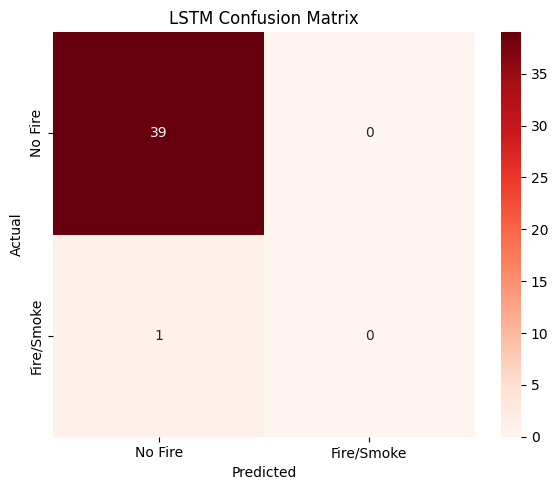

In [12]:
# Predict on validation set
y_pred_prob = lstm_model.predict(X_val, verbose=0).flatten()
y_pred      = (y_pred_prob > 0.5).astype(int)

print("=== LSTM PERFORMANCE ===")
print(classification_report(y_val, y_pred,
      target_names=['No Fire', 'Fire/Smoke']))

# Confusion matrix
cm  = confusion_matrix(y_val, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No Fire','Fire/Smoke'],
            yticklabels=['No Fire','Fire/Smoke'],
            ax=ax)
ax.set_title('LSTM Confusion Matrix')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'lstm_confusion_matrix.png'), dpi=100)
plt.show()

In [13]:
def get_cctv_confidence(image_paths, conf_threshold=0.25):
    """
    Full pipeline: takes a sequence of 10 image paths,
    runs YOLO + optical flow + LSTM,
    returns final confidence score for fusion engine.

    Input  : list of 10 image file paths
    Output : dict with cctv_confidence score
    """
    if len(image_paths) < SEQUENCE_LEN:
        return {'cctv_confidence': 0.0, 'error': 'Need 10 frames'}

    # Extract features for each frame
    sequence = []
    for i, img_path in enumerate(image_paths[-SEQUENCE_LEN:]):
        prev_path = image_paths[i-1] if i > 0 else None
        features  = extract_frame_features(img_path, prev_path)
        sequence.append(features)

    # Normalise
    X_seq    = np.array(sequence, dtype=np.float32)
    X_flat   = X_seq.reshape(-1, N_FEATURES)
    X_scaled = scaler.transform(X_flat).reshape(1, SEQUENCE_LEN, N_FEATURES)

    # LSTM prediction
    lstm_conf = float(lstm_model.predict(X_scaled, verbose=0)[0][0])

    # YOLO max confidence across sequence
    yolo_confs = [extract_frame_features(p)[ 3] for p in image_paths[-5:]]
    yolo_conf  = max(yolo_confs) if yolo_confs else 0.0

    # Combined score (weighted)
    cctv_confidence = round(0.6 * lstm_conf + 0.4 * yolo_conf, 4)

    # Get last frame detections for dashboard
    last_result = detector(
        cv2.imread(image_paths[-1]),
        conf=conf_threshold, verbose=False)[0]

    return {
        'cctv_confidence' : cctv_confidence,   # → goes to fusion engine
        'lstm_confidence' : round(lstm_conf, 4),
        'yolo_confidence' : round(yolo_conf, 4),
        'fire_detected'   : any(int(c)==1 for c in last_result.boxes.cls),
        'smoke_detected'  : any(int(c)==0 for c in last_result.boxes.cls),
        'n_fire'          : sum(1 for c in last_result.boxes.cls if int(c)==1),
        'n_smoke'         : sum(1 for c in last_result.boxes.cls if int(c)==0),
        'bbox'            : [list(map(int, b)) for b in last_result.boxes.xyxy],
    }

# Test the function
sample_sequence = [
    os.path.join(TEST_IMG, f)
    for f in sorted(test_files)[:10]
]
result = get_cctv_confidence(sample_sequence)

print("=== FINAL OUTPUT TO FUSION ENGINE ===")
for k, v in result.items():
    print(f"  {k:20s}: {v}")

=== FINAL OUTPUT TO FUSION ENGINE ===
  cctv_confidence     : 0.40799999237060547
  lstm_confidence     : 0.4913
  yolo_confidence     : 0.28299999237060547
  fire_detected       : False
  smoke_detected      : False
  n_fire              : 0
  n_smoke             : 0
  bbox                : []


In [14]:
import pickle

# Save LSTM model
lstm_model.save(os.path.join(OUTPUT_DIR, 'lstm_model.h5'))

# Save scaler
with open(os.path.join(OUTPUT_DIR, 'lstm_scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

# Save final config for Person 4 (Fusion Engine)
nb3_config = {
    'YOLO_MODEL'     : BEST_MODEL_PATH,
    'LSTM_MODEL'     : os.path.join(OUTPUT_DIR, 'lstm_model.h5'),
    'SCALER'         : os.path.join(OUTPUT_DIR, 'lstm_scaler.pkl'),
    'SEQUENCE_LEN'   : SEQUENCE_LEN,
    'N_FEATURES'     : N_FEATURES,
    'CLASS_NAMES'    : CLASS_NAMES,
    'OUTPUT_DIR'     : OUTPUT_DIR,
    'map50'          : nb2_config.get('map50', 0),
    'precision'      : nb2_config.get('precision', 0),
    'recall'         : nb2_config.get('recall', 0),
}

with open(os.path.join(OUTPUT_DIR, 'nb3_config.json'), 'w') as f:
    json.dump(nb3_config, f, indent=2)

print("=" * 45)
print("  Notebook 3 COMPLETE!")
print("=" * 45)
print(f"\nFiles saved to {OUTPUT_DIR}:")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath)
        print(f"  {fname:40s} {size/1024:.1f} KB")

print("\nOutput for Person 4 (Fusion Engine):")
print("  - lstm_model.h5       → LSTM weights")
print("  - lstm_scaler.pkl     → feature scaler")
print("  - nb3_config.json     → all paths and settings")
print("  - Function: get_cctv_confidence(image_paths) → returns cctv_confidence score")

  Notebook 3 COMPLETE!

Files saved to /kaggle/working:
  lstm_best.h5                             414.4 KB
  lstm_confusion_matrix.png                19.1 KB
  lstm_model.h5                            414.4 KB
  lstm_scaler.pkl                          0.6 KB
  lstm_training_curves.png                 63.9 KB
  nb3_config.json                          0.4 KB
  optical_flow.png                         890.9 KB
  yolo_single_test.png                     560.7 KB

Output for Person 4 (Fusion Engine):
  - lstm_model.h5       → LSTM weights
  - lstm_scaler.pkl     → feature scaler
  - nb3_config.json     → all paths and settings
  - Function: get_cctv_confidence(image_paths) → returns cctv_confidence score
